Name: Doria, Atasha Frances Gayle S.


### Instructions
1. Fill in the code/text blocks to answer each question.
2. Do *not* change any of the existing code provided.
3. Run the entire notebook to make sure that the code actually runs without errors. 

### [Problem 1] The Distribution of Words in a Human Language: Zipf's Law 

In this problem, you will be looking at a phenomenon of "natural languages" (i.e., human languages, such as English). As it turns out, when we look at the distribution of words in a different human languages, the distribution roughly follows what's called *Zipf's law* ([Wikipedia](https://en.wikipedia.org/wiki/Zipf%27s_law)). **Throughout this problem, do not remove stopwords.**

*Zipf's law* states that given a large sample of words used, any word's frequency is inversely proportional to its rank in the frequency table (the word with rank 1 is the most frequently occurring word, the word with rank 2 is the second most frequently occurring word, etc). In this problem, you are going to test Zipf's law on a real dataset and explore some of its properties.

This problem assumes you have already installed the `spaCy` package ([https://spacy.io](https://spacy.io)). Instructions for installing this are part of the tutorial file "`Anaconda, Jupyter, and spaCy setup tutorial.pdf`". You can find how to access lemmatized tokens using `spaCy` by looking at the `spaCy` demo Jupyter notebook from lecture.

Note: For this problem, you don't actually need `spaCy`'s named entity recognition, grammatical parsing, or part-of-speech tagging. Turning these elements off when you instantiate the nlp object can substantially speed up your code.  To make sure these are off when instantiating the nlp object, call: 

`
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser', 'tagger'])
`


(a) Read the data files.

The dataset is a collection of the 100 most popular books downloaded from Gutenburg Project ([https://www.gutenberg.org/browse/scores/top](https://www.gutenberg.org/browse/scores/top)). Each file contains the text of a book. Now read all the texts from disk. This will be the corpus in this problem.

Note: Please DO NOT change the folder name or the path, and make sure you use a relative path (e.g. './HW1_Dataset/*filename*) when reading the files. When grading your homework, we will put your Jupyter notebook file and the dataset in the same folder, and run your code. 

Hint: To list all files that match a certain pattern, you can use the `glob` package. Here's an example usage:

`
import glob
print(glob.glob('./HW1_Dataset/*.txt'))
`

Hint: When debugging your code, you may want to first make sure your code runs on a few of the books rather than all 100 (for example, you can start by only having 3 of the text files in `HW1_Dataset`). Once you're confident that your solution is correct on a few text files, then run on all of them! This is a standard approach to debugging code that is meant to handle large datasets.

In [2]:
import glob

# Used to find all .txt files in the folder.
    # glob.glob is used to get list of all .txt file inside the folder.
filePaths = glob.glob('./HW1_Dataset/*.txt')

# Used to read each file and store the text in a list
books = []
for path in filePaths:
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        books.append(f.read())

print(f"Total of read text files: {len(books)}")

Total of read text files: 100


(b) Build the frequency table. Specifically, complete the following three tasks:

  1. Process the text by separating and lemmatizing the words.
  2. Then count the number of times each word appears in the corpus and build a frequency table. (In particular, use raw counts as the "frequency"--do not divide by the total number of words in the corpus.)
  3. Sort the table and print the top 50 most frequent words, along with their frequencies and ranks. Don't worry about ties (for example, if multiple things have the same frequency, it's fine if your solution breaks ties arbitrarily in the sorting).

Note: When counting the words, only include words (tokens) that consist of alphabetic letters (a-z and A-Z). You can do this with what's called a *regular expression*. For example, to check whether the words "will.i.am" or "Tesla" are alphabetic, you would do the following:

`
import re  # regular expression package
if re.match('[a-zA-Z]+$', 'will.i.am'):
    print('will.i.am consists only of alphabetic letters!')
if re.match('[a-zA-Z]+$', 'Tesla'):
    print('tesla consists only of alphabetic letters!')
`

In [4]:
import re # Used to check if a word contains only letters.
import spacy # Used for NLP.
from collections import Counter # Used to automatically count words.
from tqdm import tqdm # Used for the progress bar.

# Used to disabling for faster processing and less memory.
NLP = spacy.load('en_core_web_sm', disable=['ner', 'parser', 'tagger', 'lemmatizer'])

# Raised characters to process all files.
NLP.max_length = 5000000

# Used to count words
wordCounts = Counter()

# Used to display the processing progress, feed the books into chuncks, and process the words.
for text in tqdm(books, desc="Processing books"):
    chunkSize = 100000
    for start in range(0, len(text), chunkSize):
        chunk = text[start:start + chunkSize]
        doc = NLP(chunk)
        # Used to convert text cases and treat is as the same word.
        for token in doc:
            lemma = token.text.lower()
            # Used to check if the word has the a-z/A-Z characters to vefiry if it is a word.
            if re.match('[a-zA-Z]+$', lemma):
                wordCounts[lemma] += 1

# Used to return the list fo word and its counts from highest to lowest frequency.
sortedWords = wordCounts.most_common()

# Used to print table of the top 50 most frequent words along with their frequency and ranks.
print(f"\n{'Rank':<6} {'Word':<20} {'Frequency'}")
print("-" * 35)
for rank, (word, freq) in enumerate(sortedWords[:50], start=1):
    print(f"{rank:<6} {word:<20} {freq}")

Processing books: 100%|██████████| 100/100 [16:28<00:00,  9.89s/it]


Rank   Word                 Frequency
-----------------------------------
1      the                  702489
2      and                  435420
3      of                   386341
4      to                   324426
5      a                    233677
6      in                   204229
7      i                    197240
8      that                 159009
9      it                   135435
10     he                   134654
11     was                  115492
12     his                  108536
13     is                   105415
14     you                  102595
15     with                 101221
16     not                  95515
17     for                  95333
18     as                   90801
19     be                   78826
20     but                  75597
21     my                   74062
22     had                  72636
23     her                  68351
24     at                   64984
25     on                   62868
26     by                   61980
27     have               

(c) Visualize the frequency table by plotting a **raw scatter plot** (put frequency as the y-axis and rank as the x-axis), and a **log-log plot** (use logarithmic scales on both the x- and y- axes). Note that this should be for all words and not only the top 50. As before, for the ranks, do not worry about ties, i.e., break ties arbitrarily.

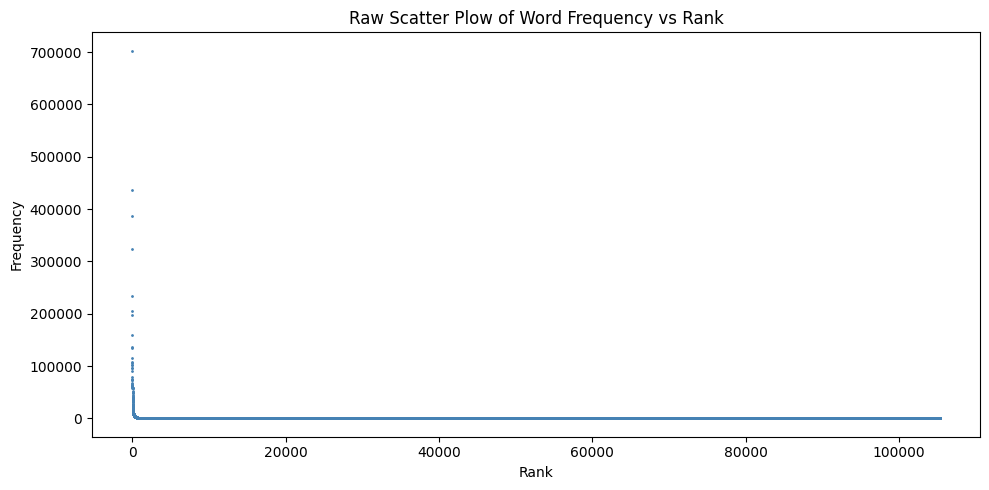

In [5]:
import matplotlib.pyplot as plt

# Use to extract the frquency numbers from the sortedWords into a plain list.
frequencies = [freq for word, freq in sortedWords]

# Used to create a list of rank numbers with the total of unique words.
ranks = list(range(1, len(frequencies) + 1))

# Creates a canvas for the plot.
plt.figure(figsize=(10, 5))

# Used to create the scatter plot witht the x and y axis assigned.
plt.scatter(ranks, frequencies, s=1, color='steelblue') 
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title('Raw Scatter Plow of Word Frequency vs Rank')
plt.tight_layout()
plt.show()

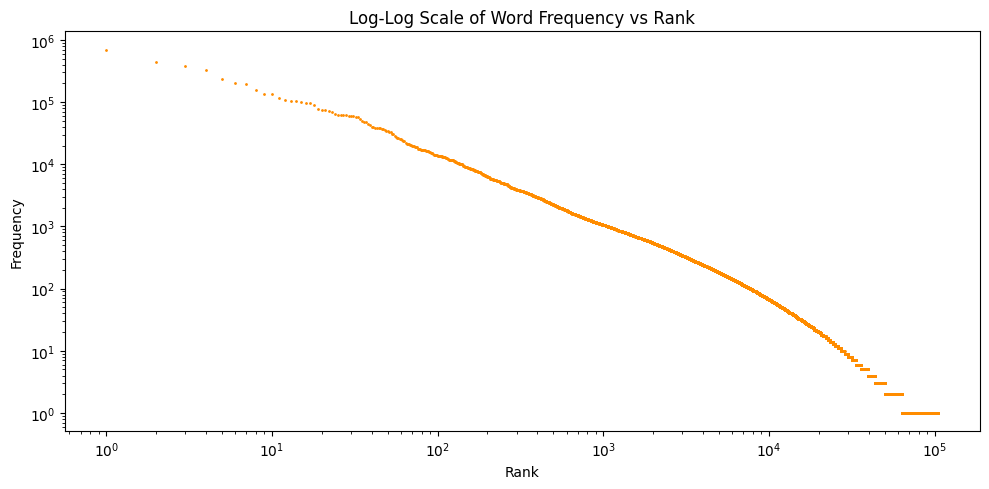

In [6]:
plt.figure(figsize=(10, 5))
plt.scatter(ranks, frequencies, s=1, color='darkorange')

# Used to the logarithmic scale on the x-axis.
plt.xscale('log')  

# Used to the logarithmic scale on the y-axis.
plt.yscale('log')  
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title('Log-Log Scale of Word Frequency vs Rank')
plt.tight_layout()
plt.show()

(d) Explore the frequency table: Zipf's law states that term frequency is governed by a power low, i.e. the relationship between term frequency and rank can be approximated by $f(r) = cr^{-1}$, where $f(r)$ is the frequency of the term at rank $r$, $r$ is the rank of a term, and $c$ is a constant and is approximately 0.1*(corpus size) for English. 

Answer following questions:

- What do you observe in the log-log plot above? Is this consist with the power law?

Your text answer (for this question, your answer is *not* code): ***Primarily focusing on the straight diagonal line to the right, the distribution matches with the Zipf's power law. It shows that a word frequency is inversely proportional to the rank, as the points formed a straight diagonal line with a negative slope. However, there is a bit of deviations at the end for the rare word.***

- Think of the corpus as a (large) unigram bag of words. Following the analogy from lecture, imagine drawing a single word from this big bag (note that we are assuming that we've lemmatized the words and also filtered out non-alphanumeric words). What is the probability of drawing one of the 4 most frequent words? What is the probability of drawing one of the 50 most frequent words? Answer these two questions using code rather than just entering in the final answers as numbers.

In [7]:
# Used to total the number of words in tokens in the entire corpus.
totalWords = sum(wordCounts.values())

print('Probability of drawing one of the 4 most frequent words: ')

# Used to sum the frequencies of rank 1 to 4 that rounded to 4 decimal points.
top4Freq = sum(freq for word, freq in sortedWords[:4])
print(round(top4Freq / totalWords, 4))

print('Probability of drawing one of the 50 most frequent words: ')

# Used to sum the frequencies of rank 1 to 50 that rounded to 4 decimal points.
top50freq = sum(freq for word, freq in sortedWords[:50])
print(round(top50freq / totalWords, 4))

Probability of drawing one of the 4 most frequent words: 
0.1533
Probability of drawing one of the 50 most frequent words: 
0.448


- What proportion of the words occur only once? What proportion of the words occur fewer than 10 times?

In [8]:
print("Occur only once: ")
# Used to total the number of unique words which appeared once.
once = sum(1 for word, freq in sortedWords if freq == 1)
print(round(once / len(sortedWords), 4))

print("Occur fewer than 10 times: ")
# Used to total the number of unique words which appeared fewer than 10 times.
lessThan10 = sum(1 for word, freq in sortedWords if freq < 10)
print(round(lessThan10 / len(sortedWords), 4))

Occur only once: 
0.3981
Occur fewer than 10 times: 
0.7288


### [Problem 2] Entity Recognition and Pointwise Mutual Information (PMI) 
By using the entity recognition system in `spaCy`, let's identify named entities from newspaper articles. You'll be using Reuters corpus which contains more than ten thousand newspaper articles. To run the code below, you need to download the Reuters dataset. To do so, in a terminal/command line (recall that you can open a terminal from Jupyter's webpage that shows all the files, which by default is [http://localhost:8888/tree](http://localhost:8888/tree)), start up Python and enter:

`
import nltk
nltk.download('reuters')
`

Then proceed to the problem subparts below.

Note that in this problem you will need named entity recognition but not grammatical parsing or the part-of-speech tagging. Hence, you will want to instantiate the nlp object by calling:

`
nlp = spacy.load('en', disable=['parser', 'tagger'])
`


(a) Draw a bar chart in which one of the axes shows entity labels and the other shows the frequency of the corresponding label. Use the variables `reuters_nlp` and `label_counter` provided in the code below.

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2747/2882088612.py:11: SyntaxWarning: invalid escape sequence '\s'
  reuters_nlp = [nlp(re.sub('\s+',' ', reuters.raw(i)).strip()) for i in reuters_fileids]
/usr/local/python/3.12.1/lib/python3.12/site-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


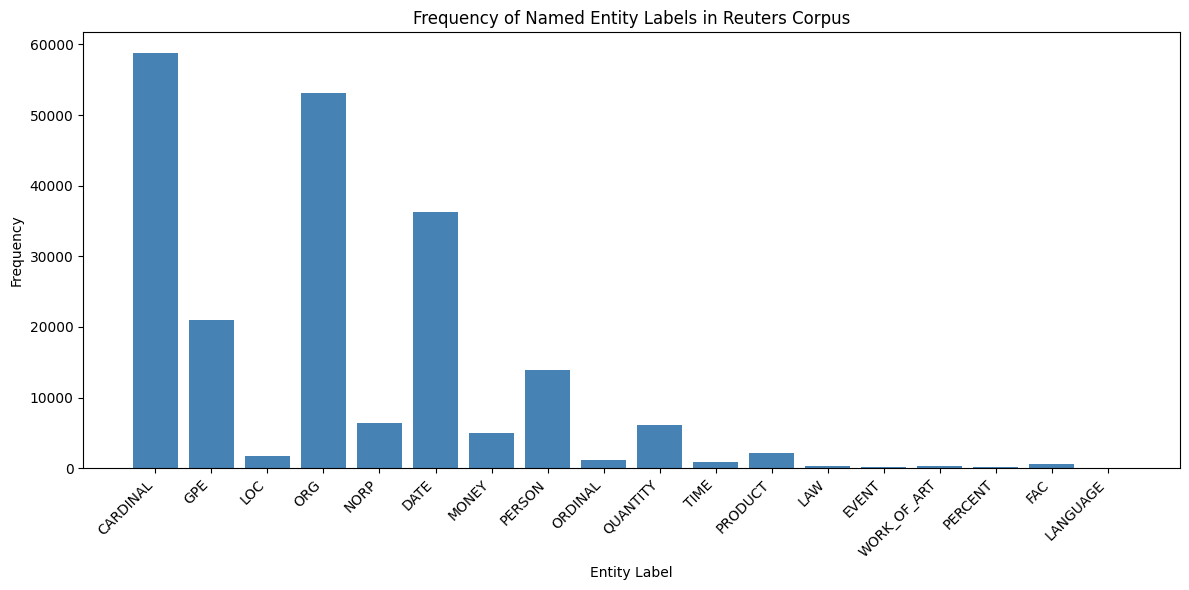

In [9]:
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import reuters
import re
import spacy

# Changed the 'en' to 'en_core_web_sm' for the updated spaCy.
nlp = spacy.load('en_core_web_sm', disable=['parser', 'tagger'])

reuters_fileids = reuters.fileids()  # hint: when first debugging, consider looking at just the first few
reuters_nlp = [nlp(re.sub('\s+',' ', reuters.raw(i)).strip()) for i in reuters_fileids]
label_counter = Counter()

# Used to count how many times wach entity label appreard across books.
for doc in reuters_nlp:
    # Used to give all named entities spaCy found in the article.
    for ent in doc.ents:
        # Used to for category of the entity.
        label_counter[ent.label_] += 1

# Used to plot the bar chart.
labels = list(label_counter.keys())
counts = list(label_counter.values())

plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color='steelblue')
plt.xlabel('Entity Label')
plt.ylabel('Frequency')
plt.title('Frequency of Named Entity Labels in Reuters Corpus')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

(b) Now list the top 10 most frequently occured entities (entity text and the number of occurence) with labels `ORG` (organization) and `GPE` (countries, cities, states) respectively.

Hint: Here, when counting the frequency, we need to count how many articles have an entity with the desired property. For every article, we add 1 if the article has the entity and 0 otherwise.  List filtering will be helpful here.

In [10]:
from collections import Counter

org_counter = Counter()
gpe_counter = Counter()

# Used to count unique entities for each article.
for doc in reuters_nlp:
    # Used set() to get unique entities per article and does not counts the same entity in multiple times.
    orgs_in_doc = set(ent.text.lower() for ent in doc.ents if ent.label_ == 'ORG')
    gpes_in_doc = set(ent.text.lower() for ent in doc.ents if ent.label_ == 'GPE')
    
    # Used to add 1 for each unique entity found.
    for org in orgs_in_doc:
        org_counter[org] += 1
    for gpe in gpes_in_doc:
        gpe_counter[gpe] += 1

print("Top 10 ORG entities:")
for entity, count in org_counter.most_common(10):
    print(f"  {entity}: {count}")

print("\nTop 10 GPE entities:")
for entity, count in gpe_counter.most_common(10):
    print(f"  {entity}: {count}")

Top 10 ORG entities:
  cts: 2886
  cts net: 536
  reuters: 443
  net shr: 272
  the securities and exchange commission: 249
  ec: 238
  fed: 223
  treasury: 209
  usda: 181
  the u.s. agriculture department: 168

Top 10 GPE entities:
  u.s.: 1607
  japan: 564
  the united states: 380
  u.k.: 302
  canada: 287
  new york: 255
  west germany: 238
  washington: 227
  london: 202
  brazil: 196


(c) Give the top 50 `GPE` (countries, cities, states) entities that have the highest Pointwise Mutual Information (PMI) values with regard to the `ORG` (organization) entity **'opec'** (your list of this top 50 should be ranked in decreasing PMI value). Did you find any unexpected results? If so, why do you think it happened? If you found some of the results to be unsurprisingly, how come? 

Hint 1: As in lecture, when computing PMI, we will compute probabilities by counting the number of documents where entities occur or co-occur.  For example, $P('opec') = \frac{number \ \ of \ \ documents \ \ containing \ \ 'opec'}{number \ \ of \ \ documents}$.  

Hint 2: To compute this ranking, you do not have to compute the full PMI equation.

In [11]:
import math

total_docs = len(reuters_nlp)

# Used to build set of docs by index that contains opec as ORG entity.
opec_docs = set()
for i, doc in enumerate(reuters_nlp):
    for ent in doc.ents:
        if ent.label_ == 'ORG' and ent.text.lower() == 'opec':
            opec_docs.add(i)
            break

p_opec = len(opec_docs) / total_docs  

# Used for each GPE to cound how many docs contain it and how many docs contain both opec and GPE.
gpe_doc_sets = {} 

for i, doc in enumerate(reuters_nlp):
    gpes_in_doc = set(ent.text.lower() for ent in doc.ents if ent.label_ == 'GPE')
    for gpe in gpes_in_doc:
        if gpe not in gpe_doc_sets:
            gpe_doc_sets[gpe] = set()
        gpe_doc_sets[gpe].add(i)

# Used to compute for the PMI of each GPE with opec.
pmi_scores = []

for gpe, doc_set in gpe_doc_sets.items():
    p_gpe = len(doc_set) / total_docs
    co_occur = len(doc_set & opec_docs)  
    
    if co_occur == 0:
        # Used to skip GPEs that did not ever appear wit opec.
        continue 
    
    p_gpe_opec = co_occur / total_docs
    pmi = math.log(p_gpe_opec / (p_gpe * p_opec))
    pmi_scores.append((gpe, pmi, co_occur))

# Used to sort PMI in descending.
pmi_scores.sort(key=lambda x: x[1], reverse=True)

print(f"Top 50 GPE entities by PMI with 'opec':\n")
print(f"{'Rank':<6} {'GPE':<25} {'PMI':<10} {'Co-occurrences'}")
print("-" * 55)
for rank, (gpe, pmi, co_occur) in enumerate(pmi_scores[:50], start=1):
    print(f"{rank:<6} {gpe:<25} {pmi:<10.4f} {co_occur}")

Top 50 GPE entities by PMI with 'opec':

Rank   GPE                       PMI        Co-occurrences
-------------------------------------------------------
1      bpd                       4.4822     2
2      lajous                    4.4822     1
3      duri                      4.4822     1
4      trinidad-tobago           4.4822     1
5      emirates                  4.4822     2
6      the lake charles          4.4822     1
7      franco-american           4.4822     1
8      bethesda                  4.4822     1
9      dd                        4.4822     1
10     dunham                    4.4822     1
11     gabon                     4.4822     2
12     aguarico                  4.4822     1
13     el salado                 4.4822     1
14     jubail                    4.4822     1
15     tripoli                   4.4822     2
16     doha                      4.4822     1
17     non-opec mexico           4.4822     1
18     guayaquil                 4.4822     2
19     redoglia 

Your text answer (for this question, your answer is *not* code): ***I have seen that GPEs like 'bpd' are also included, which inflated the PMI scores since they rarely appear but happened to mention OPEC. However, from the 23rd rank onwards, the results make more sense as they show actual OPEC member countries and capitals. Therefore, PMI does capture meaningful associations once there are enough co-occurrences to make the score statistically reliable, though it struggles with rare words.***